# Three Types of Data Analysis

### Univariate Analysis

According to Wikipedia (2022):

>  Univariate analysis is the simplest form of analyzing data. Uni means one, so in other words the data has only one variable. Univariate data requires to analyze each variable separately. Data is gathered for the purpose of answering a question, or more specifically, a research question. Univariate data does not answer research questions about relationships between variables, but rather it is used to describe one characteristic or attribute that varies from observation to observation (para 4).

Univariate (statistics). (2022, January 24). In *Wikipedia*. https://en.wikipedia.org/wiki/Univariate_(statistics).

In [1]:
# data example from https://archive.ics.uci.edu/ml/datasets/Auto+MPG
import pandas as pd

cars = pd.read_csv('https://raw.githubusercontent.com/gitmystuff/Datasets/main/auto-mpg.data', sep = '\s+', header = None)
cars.columns=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin',  'car name']
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Note About read_csv

* https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
* ',' is default since csv is used in the method name
* Defining our sep such as \s+

In [2]:
print(cars.shape)
print(cars.info())

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


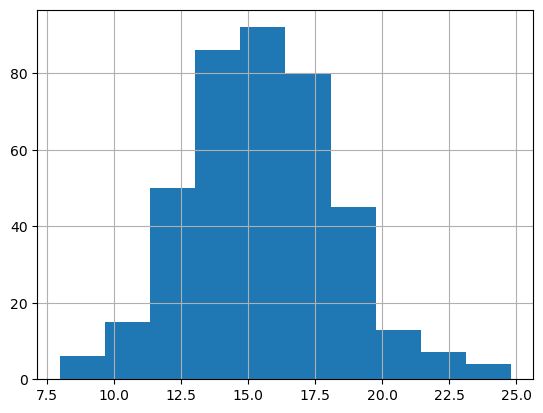

In [3]:
# example of univariate histogram
cars['acceleration'].hist();

4    204
8    103
6     84
3      4
5      3
Name: cylinders, dtype: int64


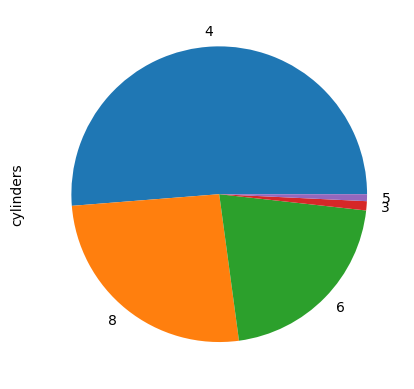

In [4]:
# example of univariate pie chart

print(cars.cylinders.value_counts())
cars.cylinders.value_counts().plot.pie();

### Bivariate Analysis

* Used to describe the relationship between two variables such as between a feature and the target
* The green lines show the numeric value of the means of the two variables
* We lose confidence the further we get from where the two means cross

Confidence intervals are about parameters not samples; e.g. the majority of the points in the OP's image are not within the shaded area (also seaborn uses 95% CIs by default). a better intuition in this example is that the data is consistent with any slope that passes through the CI. The reason it expands at the ends is because the data gives "less information" there.

https://stackoverflow.com/questions/62167783/what-does-the-background-area-mean-in-seaborn-regression-plot

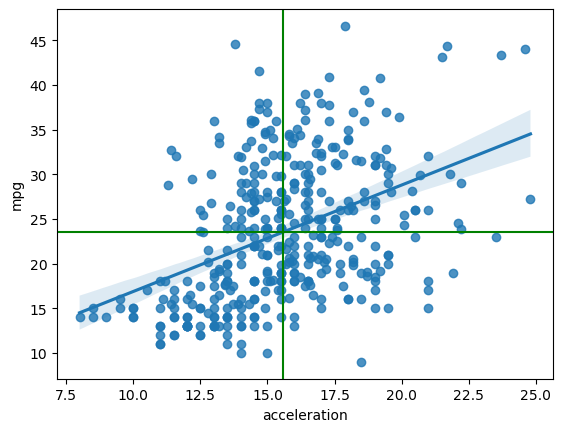

In [5]:
# bivariate scatter plot
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(data=cars, x='acceleration', y='mpg'); # recommended to not use ci with large data
plt.axvline(x=cars['acceleration'].mean(), color='green')
plt.axhline(y=cars['mpg'].mean(), color='green');

### Multivariate Analysis

Analysis using more than two variables

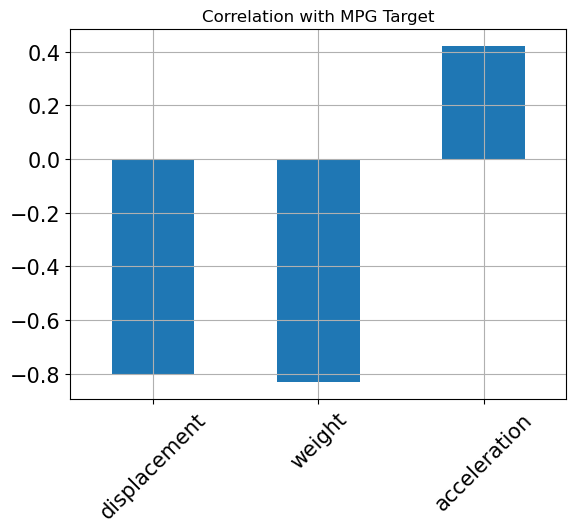

In [6]:
# showing correlation of multiple features with one target
cars[['displacement', 'horsepower', 'weight', 'acceleration']].corrwith(cars['mpg']).plot.bar(
        title = "Correlation with MPG Target", fontsize = 15,
        rot = 45, grid = True);